In [2]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt

from config_paris import Config, ObjectiveTracker
from misc import *
try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")

from inference import  prepare_true_waveform

startup


# GENERAL RESULTS FOR IMRI CASE:

IMRI params : [1000000.0, 5000.0, 0.7, 25.0, 0.25, 0.7853981633974483, 1.0, 0.9, 0.4, 0.0, 0.0]
SNR: 108.51562182222524

## 1 PA best fit points: 
	
	initial overlap: initial_overlap: 107.92359719696294
	final_overlap: 107.97942463326369  (cv bias best fit param overlap -> 107.9709067285444)
	
	x: [1000221.8808939782, 4999.747773291232, 0.7003948786264647, 24.99655848906371, 0.2499766455289157, 0.7807865861253576, 1.0162072746890254, 0.9914252791409727, 0.4069748546993725]

**will try one more time for correcting this**

## 0 PA best fit (BF) points: 
	
	
	initial overlap (at true points): 11.037468826872916
	final_overlap: 107.92398402789644
	theta0: [999731.181079391, 4997.5459544667, 0.7007325599970741, 24.998511054328947, 0.25008760356709087,

0.7811710116100292, 1.0114347544593056, 1.0739333709013787, 0.3145495163888312]

**one more time this also**
## Simple Deviation Term

	initial overlap (at true points): 11.037468826872916
	final_overlap: 107.96195706252452
	x_bf = [1002570.1299598757, 4950.1983637714975, 0.7050753237616896, 24.955671106332613, 0.24972703426218926, 0.7817115297347373, 1.0060200227981309, 0.9601402852592612, 0.46323805827618125, 1.7990568266070708, 2.0480302502976233]



[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 788953) PSD_funcs: (3, 394476)
[TRUE] SNR: 108.515622
[TRUE] SNR - Channel 0: 50.941054
[TRUE] SNR - Channel 1: 95.814277
[TRUE] SNR - Channel 2: 0.523006
[INFO] Frequency resolution delta_f: 1.267503e-07 Hz, Number of frequency bins: 394477
freq_max: 0.050000 Hz and Freq_min: 0.000000 Hz


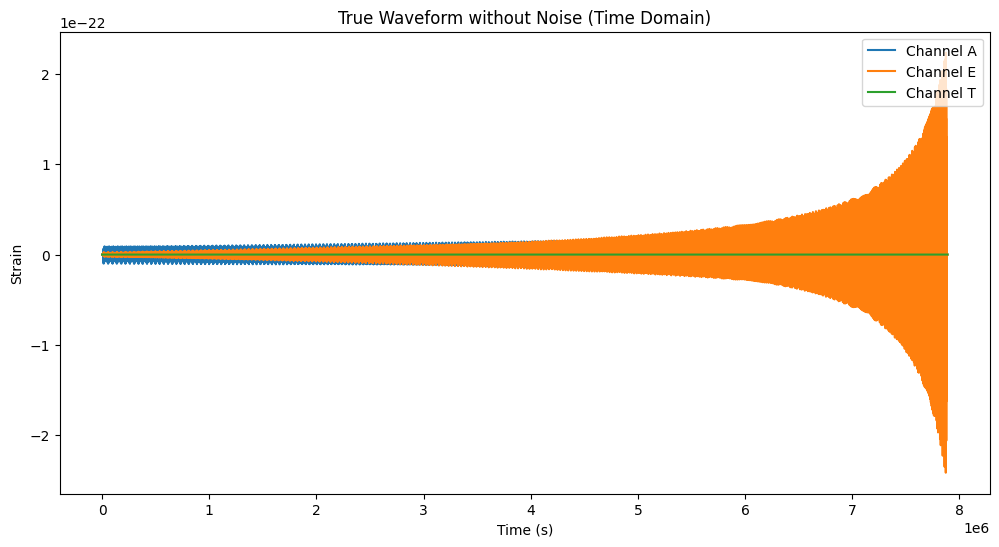

[INFO] Added noise to true waveform FFT

shape of waveform_true_fft after noise addition: (3, 394476)


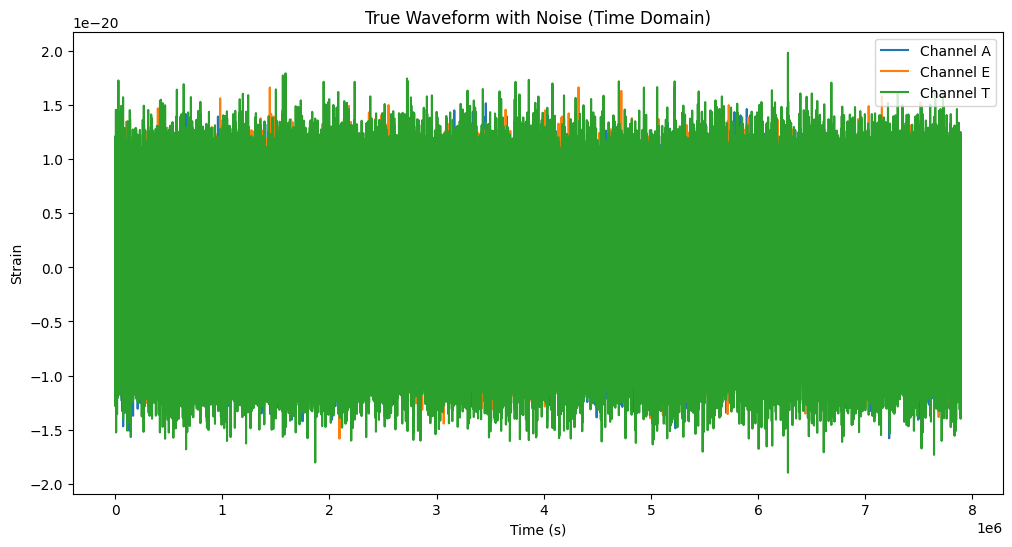

Length of PSD: 394476


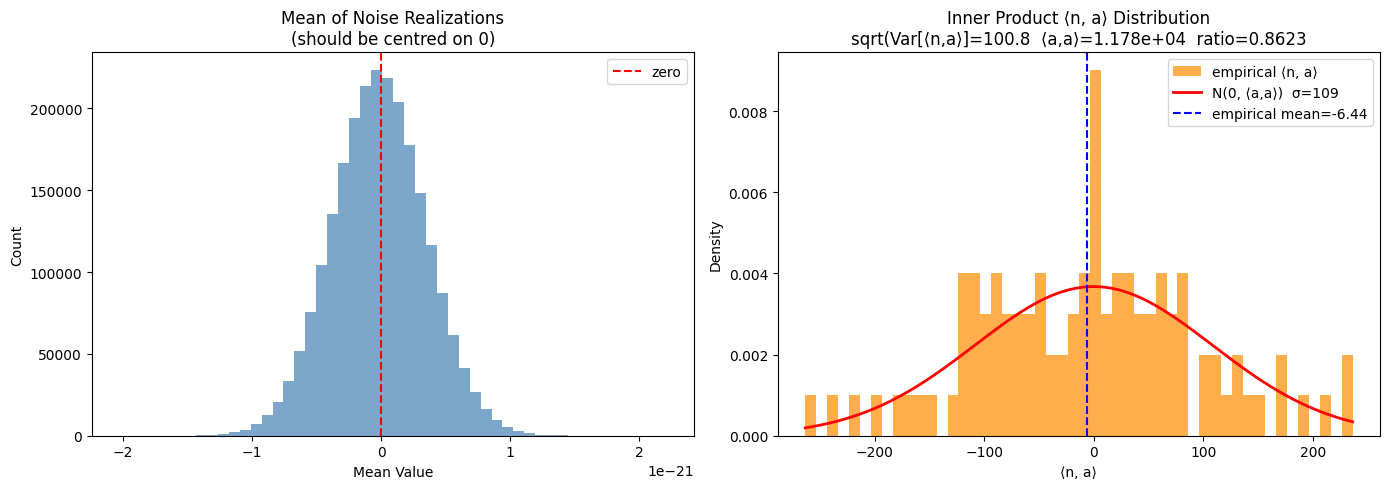

  Noise model consistency check
  Backend                : CuPy (GPU)
  Realizations           : 100
  N time samples         : 788950  |  PSD bins passed: 394475
  N (template samples)   : 788953  →  aligned to 788950
  Max |mean noise|       : 2.2122e-21  (expect ≈ 0)
  E[⟨n, a⟩]             : -6.4383e+00           (expect ≈ 0)
  Var[⟨n, a⟩]           : 10154.4
  ⟨a, a⟩                : 11775.6
  Ratio Var/⟨a,a⟩       : 0.862332          (expect ≈ 1.0)
Noise consistency check results: {'mean_noise': array([[-3.25266847e-22,  1.92187775e-22,  2.50648700e-22, ...,
         4.56458431e-22, -4.43890482e-22,  9.32194041e-24],
       [-5.20353732e-22,  6.39705629e-22, -3.64221292e-22, ...,
         8.25885366e-23,  8.59497806e-23,  2.28084011e-23],
       [-5.99126782e-23,  1.27191807e-24,  1.42936991e-22, ...,
        -6.02353237e-22,  6.64498006e-22, -1.68851937e-22]],
      shape=(3, 788950)), 'inner_products': array([  31.11618787, -126.1228669 ,   82.86971676,   52.69674709,
         

{'m1': np.float64(1000000.0),
 'm2': np.float64(5000.0),
 'a': np.float64(0.7),
 'p0': np.float64(25.0),
 'e0': np.float64(0.25),
 'Y0': np.float64(1.0),
 'dist': np.float64(3.0),
 'qS': np.float64(0.7853981633974483),
 'phiS': np.float64(1.0),
 'qK': np.float64(1.0),
 'phiK': np.float64(1.0471975511965976),
 'Phi_phi0': np.float64(0.9),
 'Phi_theta0': np.float64(0.5),
 'Phi_r0': np.float64(0.4),
 'dt': 10,
 'T': 0.25,
 'chi2': 0.95,
 'dev_1': 0.0,
 'dev_2': 0.0,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x15529215eff0>,
 'PSD_funcs': array([[4.26101649e-36, 1.06525447e-36, 4.73446683e-37, ...,
         1.61317874e-40, 1.61314534e-40, 1.61311193e-40],
        [4.26101649e-36, 1.06525447e-36, 4.73446683e-37, ...,
         1.61317874e-40, 1.61314534e-40, 1.61311193e-40],
        [4.25581070e-55, 1.70232428e-54, 3.83022963e-54, ...,
         5.36087803e-40, 5.36079136e-40, 5.36070468e-40]],
       shape=(3, 394476)),
 'waveform_true_fft': array([[-7.82118976e-16-

In [3]:
seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK",
                         "Phi_phi0","Phi_theta0","Phi_r0"]      

params = np.array([1e6,5e3,0.70, 25.0,  0.25,  1.00000000e+00,3, 
                    np.pi/4,  1.0, 1,  np.pi/3,  9.00000000e-01,   5.00000000e-01,  4.00000000e-01])

signal_param = {
    "m1": 1e6,
    "m2": 5.00000000e+03,
    "a": 0.70,
    "p0": 25.0,
    "e0": 0.25,
    "xI0": 1.0,
    "dist": 3,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.0000e-01,
}

signal_param_array = np.array(list(signal_param.values()))
dt = 10  #Time step for waveform generation; default 0.1s
T= 0.25

chi2 = 0.95 
dev_1 = 0.0
dev_2 = 0.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}

# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs,add_noise=True, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx['waveform_true_fft_without_noise'], ctx['waveform_true_fft_without_noise'], ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
ctx

In [4]:
noise_f =  ctx['noise']
Respsone = ctx['waveform_response']


/tmp/ipykernel_2338904/3268788078.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


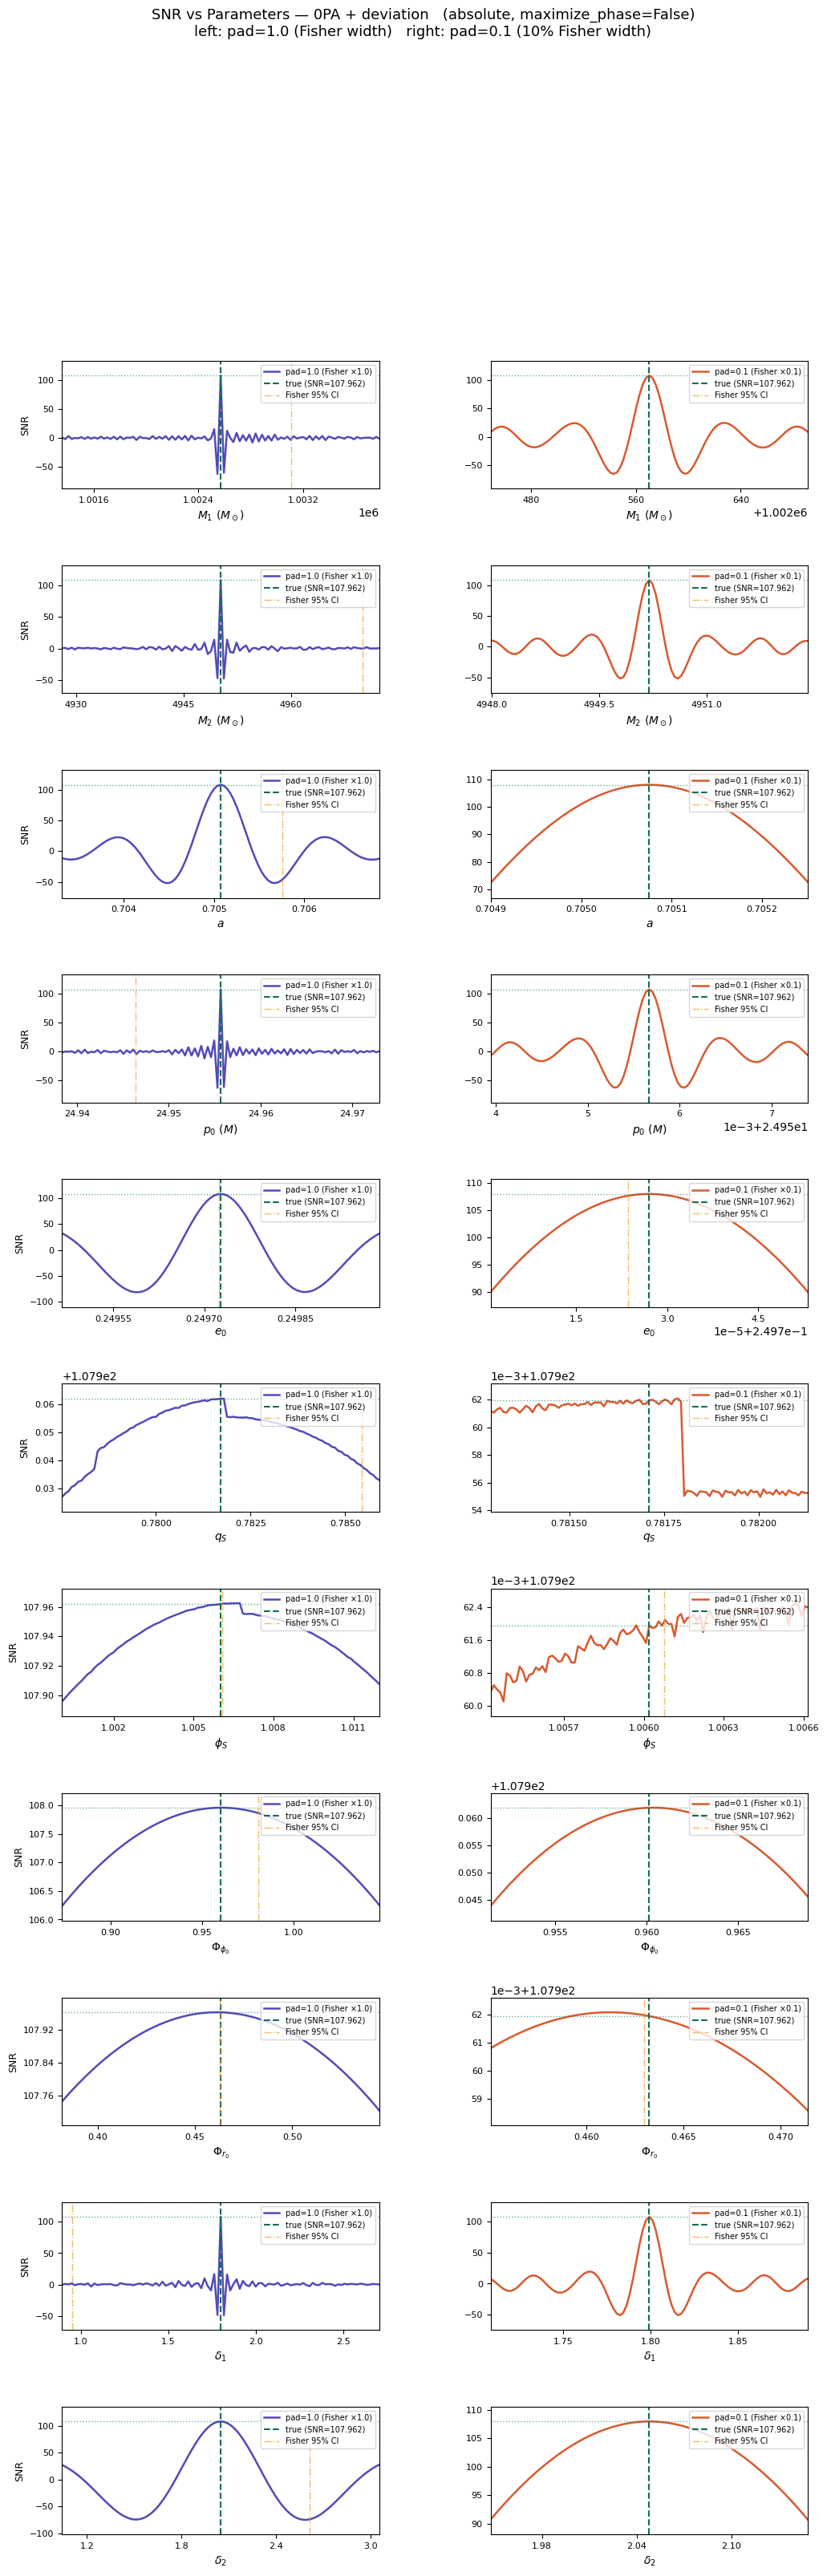

In [5]:
from matplotlib.gridspec import GridSpec

# ── Parameter setup ────────────────────────────────────────────────────────────
param_names_label = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
    r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
    r'$\delta_1$', r'$\delta_2$']

x_best_fit_0PA_dev = [1002570.1299598757, 4950.1983637714975, 0.7050753237616896,
                       24.955671106332613, 0.24972703426218926, 0.7817115297347373, 
                       1.0060200227981309, 0.9601402852592612, 0.46323805827618125,
                         1.7990568266070708, 2.0480302502976233]

bounds_0PA_dev = [(np.float64(1000683.5788093935), np.float64(1003110.4879111141)),
                  (np.float64(4925.726697461703), np.float64(4970.065590215421)), 
                  (np.float64(0.7022453392076935), np.float64(0.7057608235477748)), 
                  (np.float64(24.946371229601237), np.float64(24.980945823450366)), 
                  (np.float64(0.2497236033545224), np.float64(0.2502473097894886)), 
                  (np.float64(0.7770506167679668), np.float64(0.785431427048865)), 
                  (np.float64(0.994158315568542), np.float64(1.006076740527708)), 
                  (np.float64(0.8073169612652032), np.float64(0.9809038446384085)), 
                  (np.float64(0.4629559545442474), np.float64(0.6261789270409679)), 
                  (np.float64(0.9510953856171672), np.float64(2.766383118656904)), 
                  (np.float64(0.5990068080073618), np.float64(2.610111071330098))]

PARAM_BOUNDS = [
    (None, None),
    (None, None),
    (-0.9999, 0.9999),
    (1.0, None),
    (0.0, 0.9999),
    (0.0, np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (None, None),
    (None, None),
]

fixed = {
    'waveform_response': ctx['waveform_response'],
    'PSD':               ctx['PSD_funcs'],
    'dt':                ctx['dt'],
    'T':                 ctx['T'],
    'N_fiducial':        ctx['N_fiducial'],
    'waveform_true_fft': ctx['waveform_true_fft'],
    'xp':                np,
    'delta_f':           ctx['delta_f'],
    'use_gpu':           True,
}

N_PARAMS    = len(x_best_fit_0PA_dev)
N_POINTS    = 100
PAD_FACTORS = [1.0, 0.1]


# ── Grid builder — true point always an exact node ─────────────────────────────
def make_grid(idx, pad, n_points=N_POINTS):
    lo, hi   = bounds_0PA_dev[idx]
    half     = (hi - lo) / 2.0
    true_val = x_best_fit_0PA_dev[idx]

    raw_lo = true_val - pad * half
    raw_hi = true_val + pad * half

    phys_lo, phys_hi = PARAM_BOUNDS[idx]
    if phys_lo is not None:
        raw_lo = max(raw_lo, phys_lo)
    if phys_hi is not None:
        raw_hi = min(raw_hi, phys_hi)

    frac_left = (true_val - raw_lo) / (raw_hi - raw_lo)
    n_left    = max(2, round(n_points * frac_left))
    n_right   = max(2, n_points - n_left + 1)

    left  = np.linspace(raw_lo,   true_val, n_left)
    right = np.linspace(true_val, raw_hi,   n_right)

    return np.concatenate([left, right[1:]])


# ── SNR profile ────────────────────────────────────────────────────────────────
def compute_snr_profile(idx, pad, n_points=N_POINTS):
    grid = make_grid(idx, pad, n_points)
    snr  = np.empty(len(grid))

    theta = list(x_best_fit_0PA_dev)
    for k, x in enumerate(grid):
        theta[idx] = x
        m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_1, dev_2 = theta
        add_kwargs = {'chi2': 0.95, 'evolve_1PA': False, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': dev_1, 'dev_2': dev_2}
        snr[k] = calculate_detection_snr_0pa_vs_1pa(
            m1, m2, a, p0, e0, ctx['Y0'], ctx['dist'], qS, phiS, ctx['qK'], ctx['phiK'],
            Phi_phi0, ctx['Phi_theta0'], Phi_r0, add_kwargs,
            maximize_phase=False,
            **fixed)

    true_idx = np.argmin(np.abs(grid - x_best_fit_0PA_dev[idx]))
    snr_true = snr[true_idx]

    return grid, snr, snr_true


# ── Plotting ───────────────────────────────────────────────────────────────────
PAD_COLORS = ['#534AB7', '#D85A30']
PAD_LABELS = [f'pad={p} (Fisher ×{p})' for p in PAD_FACTORS]

def plot_snr_profiles():
    ncols = len(PAD_FACTORS)   # 2
    nrows = N_PARAMS            # 11 — grid exactly filled, no unused subplots

    fig = plt.figure(figsize=(6 * ncols, 3.2 * nrows))
    gs  = GridSpec(nrows, ncols, figure=fig, hspace=0.6, wspace=0.35)

    for idx in range(N_PARAMS):
        for col, (pad, color, label) in enumerate(zip(PAD_FACTORS, PAD_COLORS, PAD_LABELS)):
            ax = fig.add_subplot(gs[idx, col])

            grid, snr, snr_true = compute_snr_profile(idx, pad)

            ax.plot(grid, snr, color=color, lw=1.8, label=label)

            ax.axhline(snr_true, color='#0F6E56', lw=1.0, ls=':', alpha=0.6)
            ax.axvline(x_best_fit_0PA_dev[idx], color='#0F6E56',
                       lw=1.5, ls='--', label=f'true (SNR={snr_true:.3f})')

            lo, hi = bounds_0PA_dev[idx]
            ax.axvline(lo, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7)
            ax.axvline(hi, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7,
                       label='Fisher 95% CI')

            ax.set_xlim(grid[0], grid[-1])

            snr_min, snr_max = np.min(snr), np.max(snr)
            margin = (snr_max - snr_min) * 0.15 if snr_max > snr_min else abs(snr_true) * 0.01
            ax.set_ylim(snr_min - margin, snr_max + margin)

            if col == 0:
                ax.set_ylabel(r'SNR', fontsize=9)

            ax.set_xlabel(param_names_label[idx], fontsize=10)
            ax.tick_params(labelsize=8)
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))
            ax.ticklabel_format(style='sci', axis='both', scilimits=(-3, 4), useOffset=True)
            ax.legend(fontsize=7, loc='upper right')

    fig.suptitle('SNR vs Parameters — 0PA + deviation   (absolute, maximize_phase=False)\n'
                 'left: pad=1.0 (Fisher width)   right: pad=0.1 (10% Fisher width)',
                 fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    plot_snr_profiles()

In [6]:
while True:    time.sleep(1)

KeyboardInterrupt: 